# Build · The unified dataset

**This notebook is the ingest, and it is the only place the raw archive is
read.** Run it whenever the archive grows; every study downstream consumes its
output and never touches `.adc` files again.

It reads the whole archive — both column eras, all three legacy stations and
the current-era package — cleans it, compensates it, labels it, and writes one
table per station to `data/interim/unified/`.

## What it does, in order

1. **Discover** the archive extent, so the run adapts to new files without
   editing a date.
2. **Load** each legacy station and the current-era package, using the loaders
   written for each era rather than a third parser.
3. **Assemble** each station on the full archive grid, so a station that
   stopped recording is explicitly missing afterwards rather than absent.
4. **Compensate** within each era on that era's own anchor.
5. **Classify** every station: extent, coverage, channel completeness, range.
6. **Measure the changeover** between the two instruments and derive the
   offset-aligned column.
7. **Save** the tables and a manifest recording how they were built.

## What it deliberately does not do

**It fills nothing.** Every value written is a measurement, and the
`inc_source` column says so on every row. Imputation is the subject of the
companion study, which consumes this output; keeping the two apart is what
stops a filled value from being mistaken for a reading three notebooks later.

**It never joins the two eras silently.** The package installed on
2025-02-21 replaced the legacy network and its inclinometer shares no baseline
with legacy block b2 — `docs/raw-data-format.md` Section 3.3. The primary
`inc` and `inc_comp` columns keep the two baselines apart and the `era` and
`instrument` columns say which is which. A single continuous series is offered
only as `inc_comp_joined`, which carries an estimated constant and is named so
that nobody uses it by accident.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # ud_lib, local to this study
sys.path.insert(0, os.path.abspath('../../..'))   # heritageshm, at the repo root

import ud_lib as ud

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_DIR` | Read-only `.adc` archive. Never written to. |
| `CACHE_DIR` | Local working copy. Populating it from scratch is slow; it is reused across runs. |
| `OUT_DIR` | Where the unified tables are written. Gitignored. |
| `ARCHIVE_END` | Last day to read. `None` discovers the newest file present. |
| `ANALYSIS_FREQ` | Analysis grid. One hour, matching every external proxy. |
| `OFFSET_WINDOW_DAYS` | Comparison window each side of the instrument changeover. |

In [2]:
ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR = '.cache'
OUT_DIR = '../../../data/interim/unified'
OUTPUT_DIR = 'outputs'

ARCHIVE_START = ud.ARCHIVE_START
ARCHIVE_END = None             # None: discover the newest file in the archive
ANALYSIS_FREQ = ud.ANALYSIS_FREQ
STATIONS = ud.STATIONS

OFFSET_WINDOW_DAYS = 30

os.makedirs(OUTPUT_DIR, exist_ok=True)
ud.set_context('notebook')

'notebook'

## Step 1 · Read the whole archive

The legacy loader is called once per station and the current-era loader once.
Both sync the cache first, so the second and later calls cost nothing beyond
parsing.

In [3]:
frames, report = ud.load_all_stations(
    ARCHIVE_DIR, CACHE_DIR, start=ARCHIVE_START, end=ARCHIVE_END,
    freq=ANALYSIS_FREQ, stations=STATIONS, verbose=True)

print(f'\nGrid: {report["slots"]} slots at {report["freq"]}, '
      f'{report["span_days"]} days, {report["start"]} to {report["end"]}')

Archive 2018-07-26 to 2026-08-13
  legacy era : 2018-07-26 to 2025-02-20
  current era: 2025-02-21 to 2026-08-13

[legacy] st01
  cache: 1926 files in range, 0 newly copied, 1926 already present


  parsed    : 147556 records from 1926 files
  duplicates: 19210 records share a timestamp, 18473 field-level conflicts merged
  sentinels : 209459 zeros to NaN, 840 inclinometer out of range
  grid      : 172873 slots, 2018-07-26 00:00:00 to 2025-02-20 00:00:00
  resampled : 172873 native slots to 57625 at 1h; 26848 intervals carry the inclinometer, 871 rejected for holding fewer than 2 raw samples

[legacy] st02
  cache: 1926 files in range, 0 newly copied, 1926 already present


  parsed    : 147556 records from 1926 files
  duplicates: 19210 records share a timestamp, 18473 field-level conflicts merged
  sentinels : 64248 zeros to NaN, 0 inclinometer out of range
  grid      : 172873 slots, 2018-07-26 00:00:00 to 2025-02-20 00:00:00
  resampled : 172873 native slots to 57625 at 1h; 39499 intervals carry the inclinometer, 599 rejected for holding fewer than 2 raw samples

[legacy] st03
  cache: 1926 files in range, 0 newly copied, 1926 already present


  parsed    : 147556 records from 1926 files
  duplicates: 19210 records share a timestamp, 18473 field-level conflicts merged
  sentinels : 253205 zeros to NaN, 0 inclinometer out of range
  grid      : 172873 slots, 2018-07-26 00:00:00 to 2025-02-20 00:00:00
  resampled : 172873 native slots to 57625 at 1h; 23618 intervals carry the inclinometer, 112 rejected for holding fewer than 2 raw samples

[current] st02
  cache: 419 files in range, 3 newly copied, 416 already present


  parsed  : 29821 records from 419 files
  duplicates: 17 records share a timestamp, 10 field-level conflicts merged
  sentinels : 0 zeros, 15566 Twall = -55, 3100 SR > 1400 W/m2, 0 inclinometer out of range
  grid      : 38809 slots from 2025-02-21 00:00:00 to 2026-08-14 00:00:00
  resampled : 38809 native slots to 12937 at 1h; 9982 intervals carry the inclinometer, 10 rejected for holding fewer than 2 raw samples

Grid: 70561 slots at 1h, 2940.0 days, 2018-07-26 00:00:00 to 2026-08-13 00:00:00


## Step 2 · Classify every station

Which stations are usable for what. Asked once here so that nothing downstream
has to rediscover that two of the three stopped recording in February 2025.

In [4]:
classification = ud.classify_stations(frames, freq=ANALYSIS_FREQ)
display(classification)
classification.to_csv(f'{OUTPUT_DIR}/U_01_station_classification.csv')

,eras,first_reading,last_reading,span_days,observed_hours,observed_days,coverage_of_span_%,coverage_of_archive_%,batt_%,tair_%,rh_%,inc_%,sr_%,twall_%,inc_min,inc_max
station,,,,,,,,,,,,,,,,
st01,legacy,2018-07-26 00:00:00,2022-06-01 07:00:00,1406.3,26848,1118.7,79.5,38.0,38.4,38.4,38.4,38.0,0.0,0.0,-1975.00,-440.83
st02,legacy+current,2018-07-26 00:00:00,2026-08-13 00:00:00,2940.0,49463,2061.0,70.1,70.1,70.1,70.1,70.1,70.1,12.7,6.7,-1712.12,-200.04
st03,legacy,2018-07-26 00:00:00,2023-06-24 15:00:00,1794.6,23618,984.1,54.8,33.5,33.5,33.5,33.5,33.5,0.0,0.0,-1917.79,-81.62


## Step 3 · The two eras, side by side

Only the target station spans both.

In [5]:
profiles = {}
for station in STATIONS:
    profile = ud.era_profile(frames[station], freq=ANALYSIS_FREQ)
    profiles[station] = profile
    print(f'\n=== {station} ===')
    display(profile)

era_table = pd.concat(profiles, names=['station'])
era_table.to_csv(f'{OUTPUT_DIR}/U_02_era_profiles.csv')


=== st01 ===


,from,to,slots,span_days,annual_cycles,batt_%,tair_%,rh_%,inc_%,sr_%,twall_%,inc_mean,inc_sd
era,,,,,,,,,,,,,
legacy,2018-07-26,2025-02-20,57625,2401.0,6.57,47.1,47.1,47.1,46.6,0.0,0.0,-655.47,127.09



=== st02 ===


,from,to,slots,span_days,annual_cycles,batt_%,tair_%,rh_%,inc_%,sr_%,twall_%,inc_mean,inc_sd
era,,,,,,,,,,,,,
legacy,2018-07-26,2025-02-20,57625,2401.0,6.57,68.5,68.5,68.5,68.5,0.0,0.0,-304.34,41.37
current,2025-02-21,2026-08-13,12913,538.0,1.47,77.2,77.2,77.2,77.2,69.1,36.8,-319.15,50.49



=== st03 ===


,from,to,slots,span_days,annual_cycles,batt_%,tair_%,rh_%,inc_%,sr_%,twall_%,inc_mean,inc_sd
era,,,,,,,,,,,,,
legacy,2018-07-26,2025-02-20,57625,2401.0,6.57,41.0,41.0,41.0,41.0,0.0,0.0,-278.39,162.04


## Step 4 · The instrument changeover

The two `inc` series either side of 2025-02-21 belong to different
instruments. The step between them is estimated here so that the derived
joined column can exist, and the estimate is reported with the one diagnostic
that would invalidate it: the ratio of diurnal amplitudes, which compares the
instruments' gain rather than their zero. A ratio far from one means a
constant offset cannot reconcile them and the joined column should not be
used.

In [6]:
offset_info = ud.estimate_era_offset(
    frames[ud.TARGET_STATION], window_days=OFFSET_WINDOW_DAYS,
    deseason=True, target='inc_comp')

offset_table = pd.Series(offset_info).to_frame('value')
display(offset_table)
offset_table.to_csv(f'{OUTPUT_DIR}/U_03_era_offset.csv')

print(f'\nRaw step across the changeover : '
      f'{offset_info["raw_step"]:+.2f} mdeg')
print(f'Attributable to the season     : '
      f'{offset_info.get("seasonal_step", float("nan")):+.2f} mdeg')
print(f'Attributed to the instrument   : '
      f'{offset_info["offset"]:+.2f} mdeg')
print(f'Diurnal amplitude, before/after: '
      f'{offset_info["diurnal_amp_before"]:.2f} / '
      f'{offset_info["diurnal_amp_after"]:.2f} mdeg '
      f'(ratio {offset_info["gain_ratio"]:.2f})')

,value
left_end,2025-02-19 23:00:00
right_start,2025-02-21 00:00:00
interruption_days,1.04
n_before,720
n_after,717
mean_before,117.731
mean_after,-9.937
raw_step,-127.667
seasonal_step,4.809
deseasoned_step,-132.476



Raw step across the changeover : -127.67 mdeg
Attributable to the season     : +4.81 mdeg
Attributed to the instrument   : -132.48 mdeg
Diurnal amplitude, before/after: 13.38 / 17.91 mdeg (ratio 1.34)


## Step 5 · Derive the joined column

Applied to the target station only, because it is the only one spanning both
eras.

In [7]:
frames[ud.TARGET_STATION] = ud.apply_era_join(
    frames[ud.TARGET_STATION], offset_info['offset'],
    target='inc_comp', out_col='inc_comp_joined')

target = frames[ud.TARGET_STATION]
print(f'{ud.TARGET_STATION}: {len(target)} rows, columns: '
      f'{list(target.columns)}')
display(target.loc[target["inc"].notna()].head(3))

st02: 70561 rows, columns: ['batt', 'tair', 'rh', 'inc', 'sr', 'twall', 'era', 'instrument', 'inc_comp', 'inc_source', 'station', 'inc_comp_joined']


,batt,tair,rh,inc,sr,twall,era,instrument,inc_comp,inc_source,station,inc_comp_joined
datetime,,,,,,,,,,,,
2018-07-26 00:00:00,3.473333,21.356667,44.898333,-378.666667,NaN,NaN,legacy,legacy_block_st02,0.000000,observed,st02,0.000000
2018-07-26 01:00:00,3.470000,20.861667,45.828333,-379.875000,NaN,NaN,legacy,legacy_block_st02,1.266667,observed,st02,1.266667
2018-07-26 02:00:00,3.473333,20.746667,46.496667,-380.791667,NaN,NaN,legacy,legacy_block_st02,0.925000,observed,st02,0.925000


## Step 6 · A look at what was built

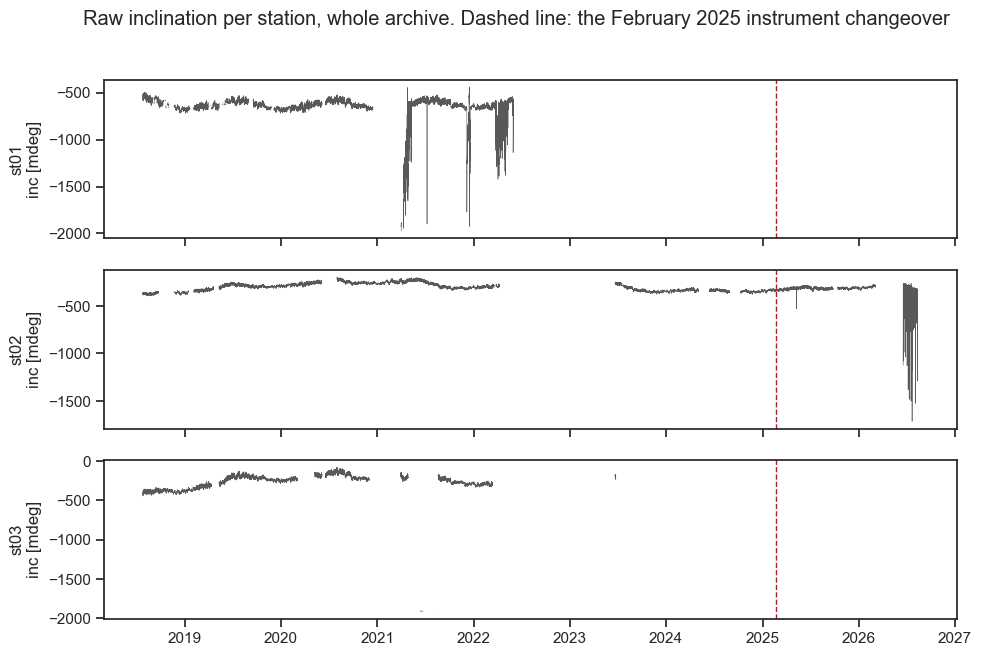

In [8]:
fig, axes = plt.subplots(len(STATIONS), 1, figsize=ud.figsize(11, 7),
                         sharex=True)
for ax, station in zip(axes, STATIONS):
    df = frames[station]
    ax.plot(df.index, df['inc'], lw=0.4, color='0.35')
    ax.set_ylabel(f'{station}\ninc [mdeg]')
    ax.axvline(pd.Timestamp(ud.CURRENT_START), color='#A5202B', lw=1.0,
               ls='--')
axes[-1].set_xlabel('')
fig.suptitle('Raw inclination per station, whole archive. '
             'Dashed line: the February 2025 instrument changeover')
fig.savefig(f'{OUTPUT_DIR}/U_F01_stations_raw.png', dpi=150,
            bbox_inches='tight')
plt.show()

The two baselines either side of the dashed line are unrelated, which is why
the primary columns keep them apart.

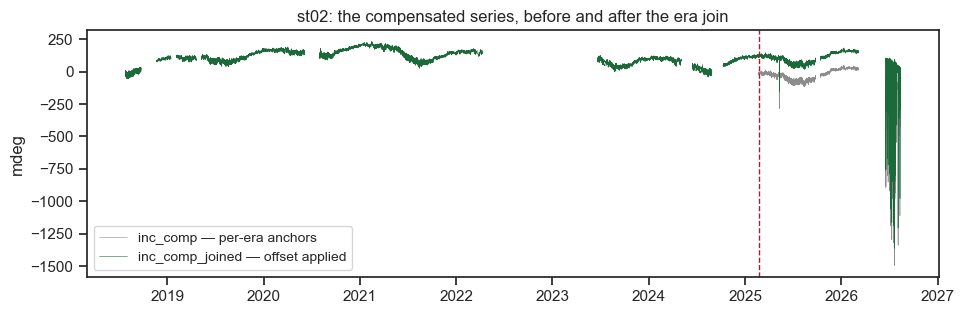

In [9]:
fig, ax = plt.subplots(figsize=ud.figsize(11, 3.2))
ax.plot(target.index, target['inc_comp'], lw=0.4, color='0.55',
        label='inc_comp — per-era anchors')
ax.plot(target.index, target['inc_comp_joined'], lw=0.4, color='#1B6B3A',
        label='inc_comp_joined — offset applied')
ax.axvline(pd.Timestamp(ud.CURRENT_START), color='#A5202B', lw=1.0, ls='--')
ax.set_ylabel('mdeg')
ax.legend(fontsize='small')
ax.set_title(f'{ud.TARGET_STATION}: the compensated series, before and after '
             f'the era join')
fig.savefig(f'{OUTPUT_DIR}/U_F02_era_join.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 · Save

Gated on the checks above having produced something, so that a partial run
cannot overwrite a good dataset with a broken one.

In [10]:
build_ok = (
    len(frames) == len(STATIONS)
    and all(frames[s]['inc'].notna().any() for s in STATIONS)
    and 'inc_comp_joined' in frames[ud.TARGET_STATION].columns
)
print(f'build_ok = {build_ok}')

if build_ok:
    report['era_offset'] = offset_info
    written = ud.save_unified(frames, OUT_DIR, report=report,
                              freq=ANALYSIS_FREQ)
    for key, path in written.items():
        size = os.path.getsize(path) / 1e6
        print(f'  {key:10s} {path}  ({size:.1f} MB)')
else:
    print('Build failed its checks; nothing was written.')

build_ok = True


  st01       ../../data/interim/unified/unified_st01_1h.csv  (6.3 MB)
  st02       ../../data/interim/unified/unified_st02_1h.csv  (9.3 MB)
  st03       ../../data/interim/unified/unified_st03_1h.csv  (6.0 MB)
  manifest   ../../data/interim/unified/unified_manifest.json  (0.0 MB)


## What the output contains

One CSV per station, on the hourly grid, spanning the whole archive.

| Column | Meaning |
|---|---|
| `batt`, `tair`, `rh` | Supply voltage, air temperature, relative humidity |
| `inc` | Inclinometer, millidegrees about the instrument's calibrated zero. **Its absolute level carries no structural information** |
| `sr`, `twall` | Solar radiation and wall temperature. Current era, target station only |
| `inc_comp` | Compensated at the documented coefficient, anchored **within each era separately** |
| `inc_comp_joined` | The same, with the estimated instrument offset removed so the two eras form one series. Target station only. Carries an estimated constant |
| `era` | `legacy` or `current` |
| `instrument` | Which physical instrument produced the row |
| `inc_source` | `observed` or `missing`. Every row written here is one or the other; nothing is filled |
| `station` | Station identifier |

The manifest beside them records the build time, the compensation coefficient,
the archive extent, and the changeover estimate.